# FIE463 – Numerical Methods in Macroeconomics and Finance  
## Term Paper 2

---
<div style="margin-top: 30px;">

**Candidate numbers:** 269 & 250
Norwegian School of Economics (NHH)

</div>
---

<div style="margin-top: 40px; font-size: 14px; color: gray;">
Artificial intelligence tools (ChatGPT, openAI) have been used for support in this assignment. The tool has been used for code clarification, debugging, and improving language and structure. All analysis, implementation, and final solutions are our own work.
</div>

# Part 1 — Data preprocessing (SCE)

## Importing packages

In [1]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import warnings

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, LassoCV, LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, balanced_accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.model_selection import validation_curve, GridSearchCV
from sklearn.linear_model import Lasso
from sklearn.linear_model import lasso_path
from sklearn.metrics import ConfusionMatrixDisplay


## 1. Import and merge SCE data

In [2]:
files = glob.glob("data/sce_extract_*.csv")

df_list = [pd.read_csv(file) for file in files]
df = pd.concat(df_list, ignore_index=True)

df_initial = df.copy()

print(f"Total observations: {len(df)}")

Total observations: 180268


We start by loading all SCE data and extracting files needed for the assingment and combine then into a single dataset. Each file contains observations from different survey waves. This leaves us with an initial dataset with 180 268 observations across all individuals and time periods. 

## 2. Forward fill variables

In [3]:
df = df.sort_values(["userid", "date"])

#only filling individual characteristics
cols_to_fill = [
    "age_init", "female", "educ", "hh_inc_bin",
    "num_kids", "owner"
] 

df[cols_to_fill] = df.groupby("userid")[cols_to_fill].ffill()

Some of the variables such as age at entry, education and gender are only recorded in the first survey wave for each of the participants. Becuase these variables are time invariant, we forward fill them within each individual over time. This makes sure that these characteristics are avaiable for all obervations without introducing incorrect variation. 

## 3. Drop observations from 2025

In [4]:
# converting date to datetime
df["date"] = pd.to_datetime(df["date"])

before = len(df)

df = df[df["date"] < "2025-01-01"]

print(f"Dropped {before - len(df)} observations")

Dropped 4167 observations


We exclude observations from 2025 to avoid potential volatility generated by the second trump administration. This ensures that we minimize the potential instability and structural breaks in the data. A total of 4 167 observations are removed.

## 4. Drop missing values

We remove observations with missing values for the selected variables

In [5]:
variables = [
    "infl_1y",
    "house_price_change",
    "prob_unrate_up",
    "prob_stocks_up"
]

before = len(df)

df = df.dropna(subset=variables)

after = len(df)

print(f"Observations before dropna: {before}")
print(f"Observations after dropna: {after}")
print(f"Dropped {before - after} observations (missing values)")


Observations before dropna: 176101
Observations after dropna: 174324
Dropped 1777 observations (missing values)


## 5. Removing outliers

In [6]:
# before trimming
before = len(df)

# create mask (true/false)
mask = pd.Series(True, index=df.index)

for var in variables:
    p1 = df[var].quantile(0.01)
    p99 = df[var].quantile(0.99)
    
    mask &= (df[var] > p1) & (df[var] < p99)

# apply mask
df = df[mask].copy()

# after trimming
after = len(df)

print(f"Observations before trimming: {before}")
print(f"Observations after trimming: {after}")
print(f"Dropped {before - after} observations (outliers)")

Observations before trimming: 174324
Observations after trimming: 159630
Dropped 14694 observations (outliers)


To reduce the influence of extreme values, we windsorize the data by keeping only the observation between between the 1st and 99th percentiles for each of the expectation variables. This limits the impact of outliers while preserving the majority of the data. After this approach 14 694 observations are removed. 

## 6. Creating indicator variables

In [7]:
df["optimist_unrate"] = (df["prob_unrate_up"] < 50).astype(int)
df["optimist_stocks"] = (df["prob_stocks_up"] > 50).astype(int)
df["optimist_house_price"] = (df["house_price_change"] > 0).astype(int)

We construct binary indicator variables to capture optimism in expectation. Individuals are classified as optimistic about uemployment if they assign a probability below 50% to uenmployment increasing.They are optimistic about atock prices if they assign a probability above 50% to stock prices increasing. They are optimistic about house prices if they expect positive price growth.  

## 7. Summary statistics

In [8]:
def format_number(x):
    return f"{x:,}"

print("=== Initial dataset ===")
print(f"Observations: {format_number(len(df_initial))}")
print(f"Individuals: {format_number(df_initial['userid'].nunique())}")
print(f"Survey periods: {format_number(df_initial['wid'].nunique())}")
print(f"Start date: {pd.to_datetime(df_initial['date']).min().strftime('%Y-%m')}")
print(f"End date: {pd.to_datetime(df_initial['date']).max().strftime('%Y-%m')}")

print(f"\n=== Final dataset ===")
print(f"Observations: {format_number(len(df))}")
print(f"Individuals: {format_number(df['userid'].nunique())}")
print(f"Survey periods: {format_number(df['wid'].nunique())}")
print(f"Start date: {df['date'].min().strftime('%Y-%m')}")
print(f"End date: {df['date'].max().strftime('%Y-%m')}")

=== Initial dataset ===
Observations: 180,268
Individuals: 23,886
Survey periods: 143
Start date: 2013-06
End date: 2025-05

=== Final dataset ===
Observations: 159,630
Individuals: 22,412
Survey periods: 139
Start date: 2013-06
End date: 2024-12


After cleaning the dataset contains 159 630 observations across 22 412 individuals and 139 survey periods, covering the period from June 2013 to December 2024. Compared to the initial dataset, the reduction in observations comes from removing missing values and outliers. The dataset have a sufficient number of observations suitable for both regression and classification analysis. 

# Part 2 — Data preprocessing (macro/finance)

In this part we supplement the dataset with macroeconomic and financial variables obtained from Yahoo Finance and FRED. These variables are merged with the survey data at the monthly level. To ensure a consistent and economically meaningful setup, we construct lagged variables and growth rates. All variables are lagged by one period so to aviod look-ahead bias and ensures that the models rely on informations that households could observe when they formed their expectations. 

## Choice of macroeconomic variables

We include the following macroeconomic and financial variables to predict household expectations:

- **S&P 500 (sp500)**: Proxy for financial market conditions and investor sentiment. Used in levels and month-over-month changes, as households may respond both to the current market level and recent momentum.
- **WTI Crude Oil (oil)**: Captures energy price shocks and input cost pressures. Changes in oil prices are particularly relevant for inflation expectations.
- **CPI (cpi)**: Direct measure of realized inflation. Included in levels and year-over-year changes, as households are likely to anchor expectations to recent inflation experience.
- **Unemployment rate (unrate)**: Measures labor market conditions. Both the level and monthly change matter — rising unemployment signals worsening conditions.
- **Federal Funds Rate (fedfunds)**: Reflects monetary policy stance. The level captures the borrowing environment; changes signal policy shifts.
- **Mortgage rate (mortgage)**: Directly affects housing affordability. Especially relevant for house price and inflation expectations.
- **House Price Index (hpi)**: Realized house price conditions; relevant for housing expectations.
- **Real GDP (gdp)**: Broad economic activity measure. Quarterly frequency — used in levels and quarter-over-quarter changes.
- **Broad Dollar Index (dollar)**: Reflects import price pressures and external competitiveness; relevant for inflation expectations.

All variables are included both in lagged levels to capture the current state of the economy at the survey time, as well as month over month changes to capture recent dynamics.  CPI is also included as a year-over-year change** since households tend to perceive inflation over longer horizons. GDP is included as quarter-over-quarter change due to its lower frequency. All variables are lagged by one period to avoid look-ahead bias.

## 1. Loading macroeconomi and financial data

In [9]:
# Yahoo
sp500    = pd.read_csv("data/sp500.csv")
oil      = pd.read_csv("data/oil.csv")

# FRED
cpi      = pd.read_csv("data/cpi.csv")
unrate   = pd.read_csv("data/unrate.csv")
fedfunds = pd.read_csv("data/fedfunds.csv")
mortgage = pd.read_csv("data/mortgage.csv")
hpi      = pd.read_csv("data/house_price.csv")
gdp      = pd.read_csv("data/Real_gross_domp.csv")
dollar   = pd.read_csv("data/US_dollar_ind.csv")

## 2. Cleaning Yahoo and FRED data

Yahoo Finance data contains extra header rows that we remove and FRED data is cleaned by renaming columns for consistency. Removing spaces and standardize lowercase. We then convert dates to datetime and then year-month, making us able to merge on month and not excact date. Also lagging the variables to ensure that only past information is usead to avoid look-ahead bias. For variables with lower observation frequency, auch as GDP and house prices, values are forward filles into intermediate months. This is to ensure that for  the information avaible to households the most recent observed value remains relevant until new data is released. For financial variables with missing months, we forward-fill values to maintain a balanced monthly panel. This approach assumes that the last observed market valu is informative where new observations is missing. Finally, we use percentage changes for price variables and absolute changes for interest rates. 

### Yahoo data

In [10]:
# keep date and price columns
sp500 = sp500.iloc[:, [0, 4]]
oil   = oil.iloc[:, [0, 4]]

# remove first two rows (Ticker, Date header rows)
sp500 = sp500.iloc[2:]
oil   = oil.iloc[2:]

# rename 
sp500.columns = ["date", "sp500"]
oil.columns   = ["date", "oil"]

# convert to numeric
sp500["sp500"] = pd.to_numeric(sp500["sp500"], errors="coerce")
oil["oil"]     = pd.to_numeric(oil["oil"], errors="coerce")

### FRED data

In [11]:
# standardise column names
cpi      = cpi.rename(columns={"observation_date": "date", "CPIAUCSL": "cpi"})
unrate   = unrate.rename(columns={"observation_date": "date", "UNRATE": "unrate"})
fedfunds = fedfunds.rename(columns={"observation_date": "date", "FEDFUNDS": "fedfunds"})
mortgage = mortgage.rename(columns={"observation_date": "date", "MORTGAGE30US": "mortgage"})
hpi      = hpi.rename(columns={"observation_date": "date", "USSTHPI": "hpi"})
gdp      = gdp.rename(columns={"observation_date": "date", "GDPC1": "gdp"})
dollar   = dollar.rename(columns={"observation_date": "date", "DTWEXBGS": "dollar"})

### Merge all data
This part consist of merging and lagging the variables. We first convert dates and resample to monthly frequences, this is done by keeping the last observation for each month. This is done due to the inconsistency between monthly SCE-data and macro-data which can be daily, monthly or quarterly. 

We also use shift to lagg the varoiables and avoid look-ahead bias. Shifting by 1 ensures the model only utilizes information available for the respondent at the time of the survey.

Thereafter, for each variable we construct three measures; levles, monthly precentage changes and yearly precentage changes. Due to GDP and HPI beeing quarterly data we forward-fill the intermediate months with last known quarterly observation. All new variables are merged to the main dataframe on year-month.

In [12]:
# convert all date columns to datetime
for d in [sp500, oil, cpi, unrate, fedfunds, mortgage, hpi, gdp, dollar]:
    d["date"] = pd.to_datetime(d["date"])

In [13]:
# aggregate all series to monthly by last observation in month
sp500    = sp500.groupby(pd.Grouper(key="date", freq="ME")).last().reset_index()
oil      = oil.groupby(pd.Grouper(key="date", freq="ME")).last().reset_index()
cpi      = cpi.groupby(pd.Grouper(key="date", freq="ME")).last().reset_index()
unrate   = unrate.groupby(pd.Grouper(key="date", freq="ME")).last().reset_index()
fedfunds = fedfunds.groupby(pd.Grouper(key="date", freq="ME")).last().reset_index()
mortgage = mortgage.groupby(pd.Grouper(key="date", freq="ME")).last().reset_index()
hpi      = hpi.groupby(pd.Grouper(key="date", freq="ME")).last().reset_index()
dollar   = dollar.groupby(pd.Grouper(key="date", freq="ME")).last().reset_index()

# GDP as quarterly 
gdp["year_month"] = gdp["date"].dt.to_period("M")

In [14]:
# add year_month to all monthly series and main df
for d in [df, sp500, oil, cpi, unrate, fedfunds, mortgage, hpi, dollar]:
    d["year_month"] = d["date"].dt.to_period("M")

In [15]:
# ensure oil has full monthly coverage
full_index = pd.period_range(
    start=oil["year_month"].min(),
    end=oil["year_month"].max(),
    freq="M"
)
oil = oil.set_index("year_month").reindex(full_index)
oil.index.name = "year_month"
oil = oil.reset_index()
oil["oil"] = oil["oil"].ffill()

In [16]:
# lagged levels and changes (all shifted by 1 to avoid look-ahead bias)
sp500["sp500_lag"] = sp500["sp500"].shift(1)
sp500["sp500_mom"] = sp500["sp500"].pct_change(1).shift(1)

oil["oil_lag"]     = oil["oil"].shift(1)
oil["oil_mom"]     = oil["oil"].pct_change(1).shift(1)

cpi["cpi_lag"]     = cpi["cpi"].shift(1)
cpi["cpi_mom"]     = cpi["cpi"].pct_change(1).shift(1)
cpi["cpi_yoy"]     = cpi["cpi"].pct_change(12).shift(1)

unrate["unrate_lag"] = unrate["unrate"].shift(1)
unrate["unrate_mom"] = unrate["unrate"].diff(1).shift(1)

fedfunds["fedfunds_lag"] = fedfunds["fedfunds"].shift(1)
fedfunds["fedfunds_mom"] = fedfunds["fedfunds"].diff(1).shift(1)

mortgage["mortgage_lag"] = mortgage["mortgage"].shift(1)
mortgage["mortgage_mom"] = mortgage["mortgage"].diff(1).shift(1)

hpi["hpi_lag"]     = hpi["hpi"].shift(1)
hpi["hpi_mom"]     = hpi["hpi"].pct_change(1).shift(1)
hpi["hpi_yoy"]     = hpi["hpi"].pct_change(12).shift(1)

dollar["dollar_lag"] = dollar["dollar"].shift(1)
dollar["dollar_mom"] = dollar["dollar"].pct_change(1).shift(1)

# GDP quarterly
gdp["gdp_lag"] = gdp["gdp"].shift(1)
gdp["gdp_qoq"] = gdp["gdp"].pct_change(1).shift(1)
gdp["gdp_yoy"] = gdp["gdp"].pct_change(4).shift(1)

/var/folders/t8/py0mcjgd3lz_m_h25pvfzq780000gp/T/ipykernel_54203/2001881362.py:9: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  cpi["cpi_mom"]     = cpi["cpi"].pct_change(1).shift(1)
/var/folders/t8/py0mcjgd3lz_m_h25pvfzq780000gp/T/ipykernel_54203/2001881362.py:10: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  cpi["cpi_yoy"]     = cpi["cpi"].pct_change(12).shift(1)
/var/folders/t8/py0mcjgd3lz_m_h25pvfzq780000gp/T/ipykernel_54203/2001881362.py:22: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading

In [17]:
# merge all into main SCE dataframe
df = df.merge(sp500[["year_month", "sp500_lag", "sp500_mom"]], on="year_month", how="left")
df = df.merge(oil[["year_month", "oil_lag", "oil_mom"]], on="year_month", how="left")
df = df.merge(cpi[["year_month", "cpi_lag", "cpi_mom", "cpi_yoy"]], on="year_month", how="left")
df = df.merge(unrate[["year_month", "unrate_lag", "unrate_mom"]], on="year_month", how="left")
df = df.merge(fedfunds[["year_month", "fedfunds_lag", "fedfunds_mom"]], on="year_month", how="left")
df = df.merge(mortgage[["year_month", "mortgage_lag", "mortgage_mom"]], on="year_month", how="left")
df = df.merge(hpi[["year_month", "hpi_lag", "hpi_mom", "hpi_yoy"]], on="year_month", how="left")
df = df.merge(dollar[["year_month", "dollar_lag", "dollar_mom"]], on="year_month", how="left")

# GDP: merge then forward-fill into non-quarter-end months
df = df.merge(gdp[["year_month", "gdp_lag", "gdp_qoq", "gdp_yoy"]], on="year_month", how="left")
df = df.sort_values("year_month")
df[["gdp_lag", "gdp_qoq", "gdp_yoy"]] = df[["gdp_lag", "gdp_qoq", "gdp_yoy"]].ffill()

# HPI: also quarterly, forward-fill
df[["hpi_lag", "hpi_mom", "hpi_yoy"]] = df[["hpi_lag", "hpi_mom", "hpi_yoy"]].ffill()

# Part 3 - Exploratory data analysis (SCE)

In the third part, we look at the  distribution and time evolution of  expectation variables in the SCE data. We visualize their distributions using histograms and examine how their average values and the share of optimistic households evolve over time.

## 1. Distribution of expectations

In [18]:
# variables of interest
variables = ["infl_1y", "house_price_change", "prob_unrate_up", "prob_stocks_up"]

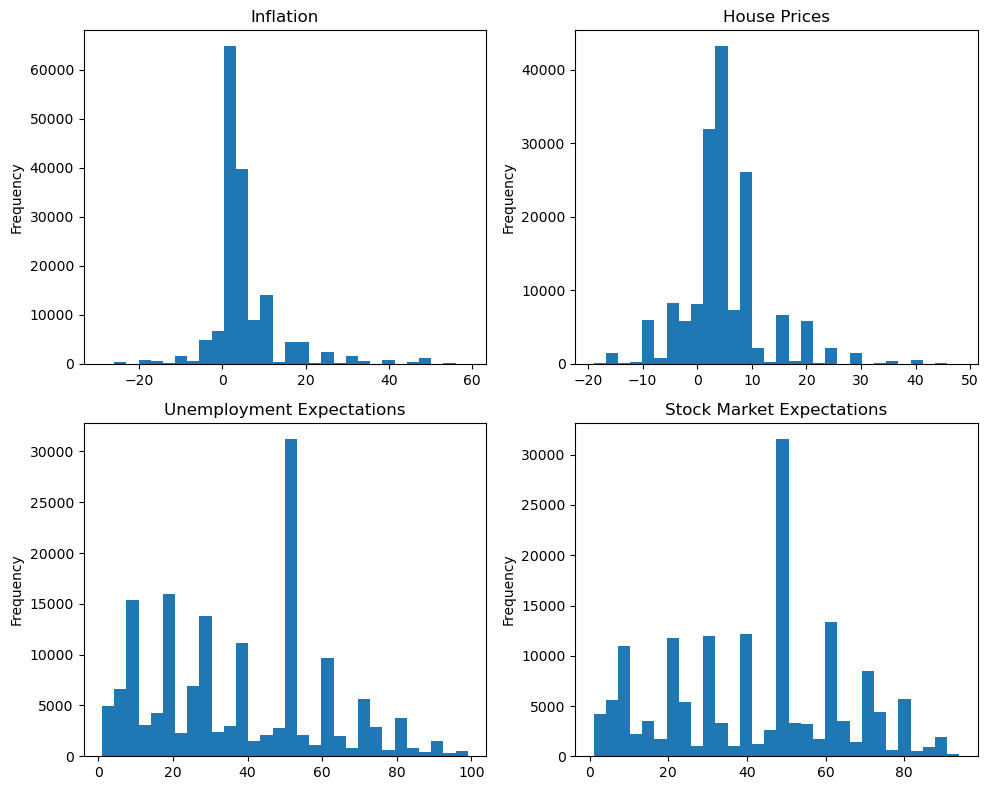

In [19]:
# titles
titles = {
    "infl_1y": "Inflation",
    "house_price_change": "House Prices",
    "prob_unrate_up": "Unemployment Expectations",
    "prob_stocks_up": "Stock Market Expectations"
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

# plot
for i, var in enumerate(variables):
    axes[i].hist(df[var], bins=30)
    axes[i].set_title(titles[var])
    axes[i].set_xlabel("")  # remove variable name on x-axis
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In the histograms we can find that inflation expectations (infl_1y) are concentrated around moderate positive values, there is also a right-skewed distribution and some extreme observations. This demonstrates that most of the households expect positive inflation, while very few households expect very high inflation outcomes. House price expectation (house_price_change) are also concentrated around positive values which tells us that in general households expect house prices to rise. We also observe that the distribution is very wide, which indicates heterogenous expectations. Furthermore, expectations about unemployment and stock market developments (prob_unrate_up and prob_stocks_up) are spread between 0 and 100, also being clustered around 50. This could indicate that respondents are uncertain and therefore report probability around 50.  

## 2. Average expectations over time


In [20]:
# group by month and take mean
df_grouped = df.groupby("year_month")[variables].mean()

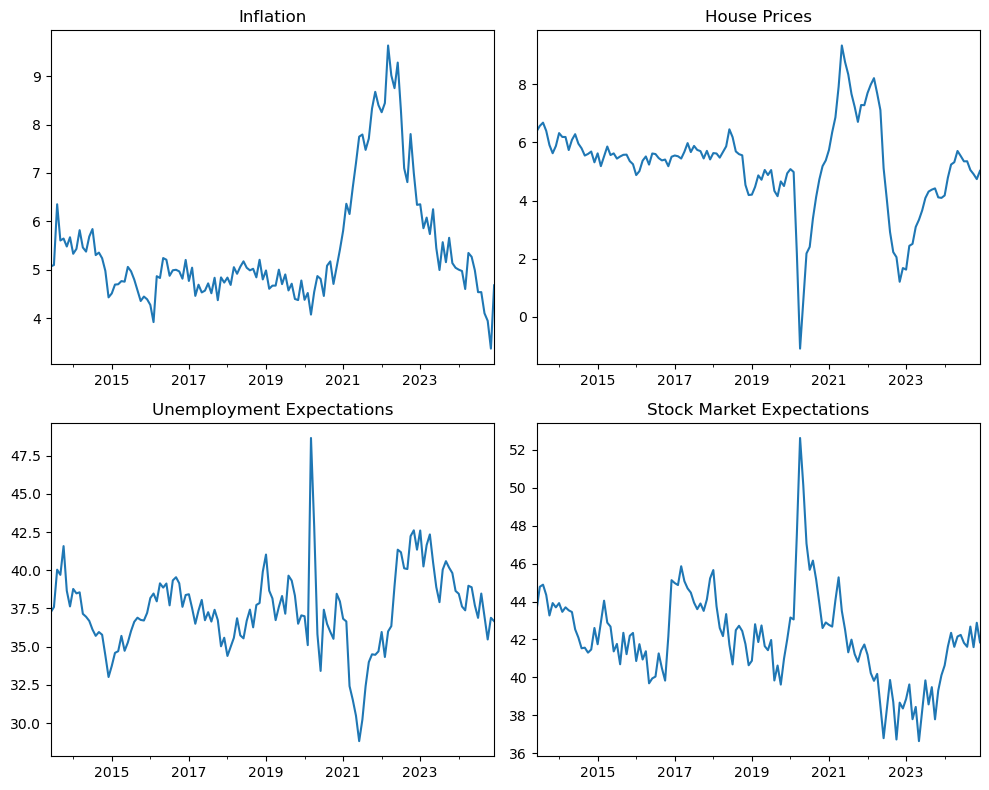

In [21]:
# titles
titles = {
    "infl_1y": "Inflation",
    "house_price_change": "House Prices",
    "prob_unrate_up": "Unemployment Expectations",
    "prob_stocks_up": "Stock Market Expectations"
}

# plot 
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, var in enumerate(variables):
    df_grouped[var].plot(ax=axes[i])
    axes[i].set_title(titles[var])
    axes[i].set_xlabel("")  # cleaner
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

The time series plots show how average expectations evolve over the survey period. The inflation expectations are relatively stable until 2020, and increase sharply after with a peak around 2021-2022. after this perid they decline again. This pattern is consistent with the increase in inflation followin the COVID-19 pandemic. 

House price expectations (house_price_change) display more volatility, with a strong drop around 2020 and a sharp increase afterward, before stabilizing again. We can assume that this is linked to the uncertainty during the pandemic, which was followed by a housing market boom, low interest rates and an increase in demand for housing. 

The probability of higher unemployment (prob_unrate_up) fluctuates over time, with noticeable spikes around 2020 to 2021, also in line with the COVID-19 macroeconomic shocks. The decline reflects the recovery in employment when the economy reopened. 
Similarly, expectations about stock market increases (prob_stocks_up) vary over time, with a clear peak around 2020–2021 and a decline afterward. This is in line with the strong recovery in financial markets following the initial pandemic shocks, which was supported by governmental monetary support. The later period could be a result of stricter monetary policy followed by increased economic uncertainty. 


## 3. Share of optimistic households

In [22]:
# grouping by month and calculating mean for the two selected variables
optimist_vars = ["optimist_unrate", "optimist_stocks", "optimist_house_price"]

df_opt = df.groupby("year_month")[optimist_vars].mean()

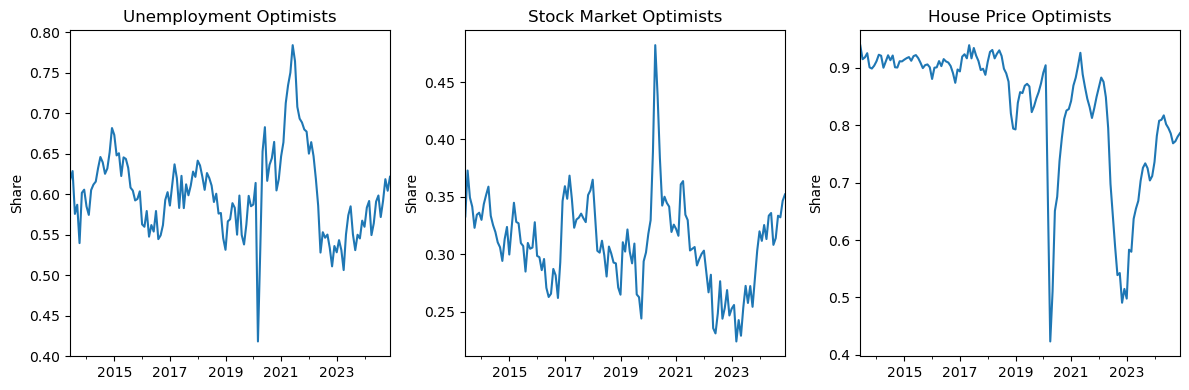

In [23]:
# titles
titles = {
    "optimist_unrate": "Unemployment Optimists",
    "optimist_stocks": "Stock Market Optimists",
    "optimist_house_price": "House Price Optimists"
}

# plot 
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes = axes.flatten()

for i, var in enumerate(optimist_vars):
    df_opt[var].plot(ax=axes[i])
    axes[i].set_title(titles[var])
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Share")

plt.tight_layout()
plt.show()

The share of optimistic households fluctuates over time across all three measures, with noticeable variation around key macroeconomic periods. This indicates that expectations are sensitive to economic conditions. Households display optimism about unemployment increases during times of improved labor markets but decreases during economic uncertainty around 2020. This demonstrates that households revise optimism in response to labor market shocks. 

Likewise, the share of stock market optimistic fluctuates over time, with an increase in 2020-2021, followed by a decline. Similarly, this suggests that optimism in financial markets is responsive to economic shocks. House price optimism is relatively high over the sample period, with a decline in 2020 and around 2023 before recovering again. This demonstrates that households are mostly optimistic around housing but also responds to economic shocks. 

Overall, the series display similar patterns, which indicate that household expectations are likely to move together over time and are strongly correlated with macroeconomic conditions. 


# Task 4 - Exploratory data analysis (macro/finance)

In task 4 we examine how macroeconomic and financial variables relate to household expectations. We plot the macro variables in both levels and changes over the SCE sample period, and compute correlations between each macro variable and the four expectation variables to identify which variables may be useful predictors.

## 1. Time series of macro variables in levels

In [24]:
# defining variables
macro_vars = ["sp500_lag", 
              "oil_lag", "cpi_lag",
              "unrate_lag", "fedfunds_lag", 
              "mortgage_lag", "hpi_lag", 
              "dollar_lag", "gdp_lag"]

# defining change variables
macro_changes = [
    "sp500_mom", "oil_mom",
    "cpi_mom", "cpi_yoy",
    "unrate_mom", "fedfunds_mom",
    "mortgage_mom", "hpi_mom", "hpi_yoy",
    "dollar_mom", "gdp_qoq", "gdp_yoy"
]

# group by year-month and taking average
df_levels  = df.groupby("year_month")[macro_vars].mean(numeric_only=True)
df_changes = df.groupby("year_month")[macro_changes].mean(numeric_only=True)

In [25]:
# titles
titles_levels = {
    "sp500_lag":    "S&P 500 (level)",
    "oil_lag":      "Oil Price (level)",
    "cpi_lag":      "CPI (level)",
    "unrate_lag":   "Unemployment Rate (level)",
    "fedfunds_lag": "Federal Funds Rate (level)",
    "mortgage_lag": "Mortgage Rate (level)",
    "hpi_lag":      "House Price Index (level)",
    "dollar_lag":   "Dollar Index (level)",
    "gdp_lag":      "Real GDP (level)",
}

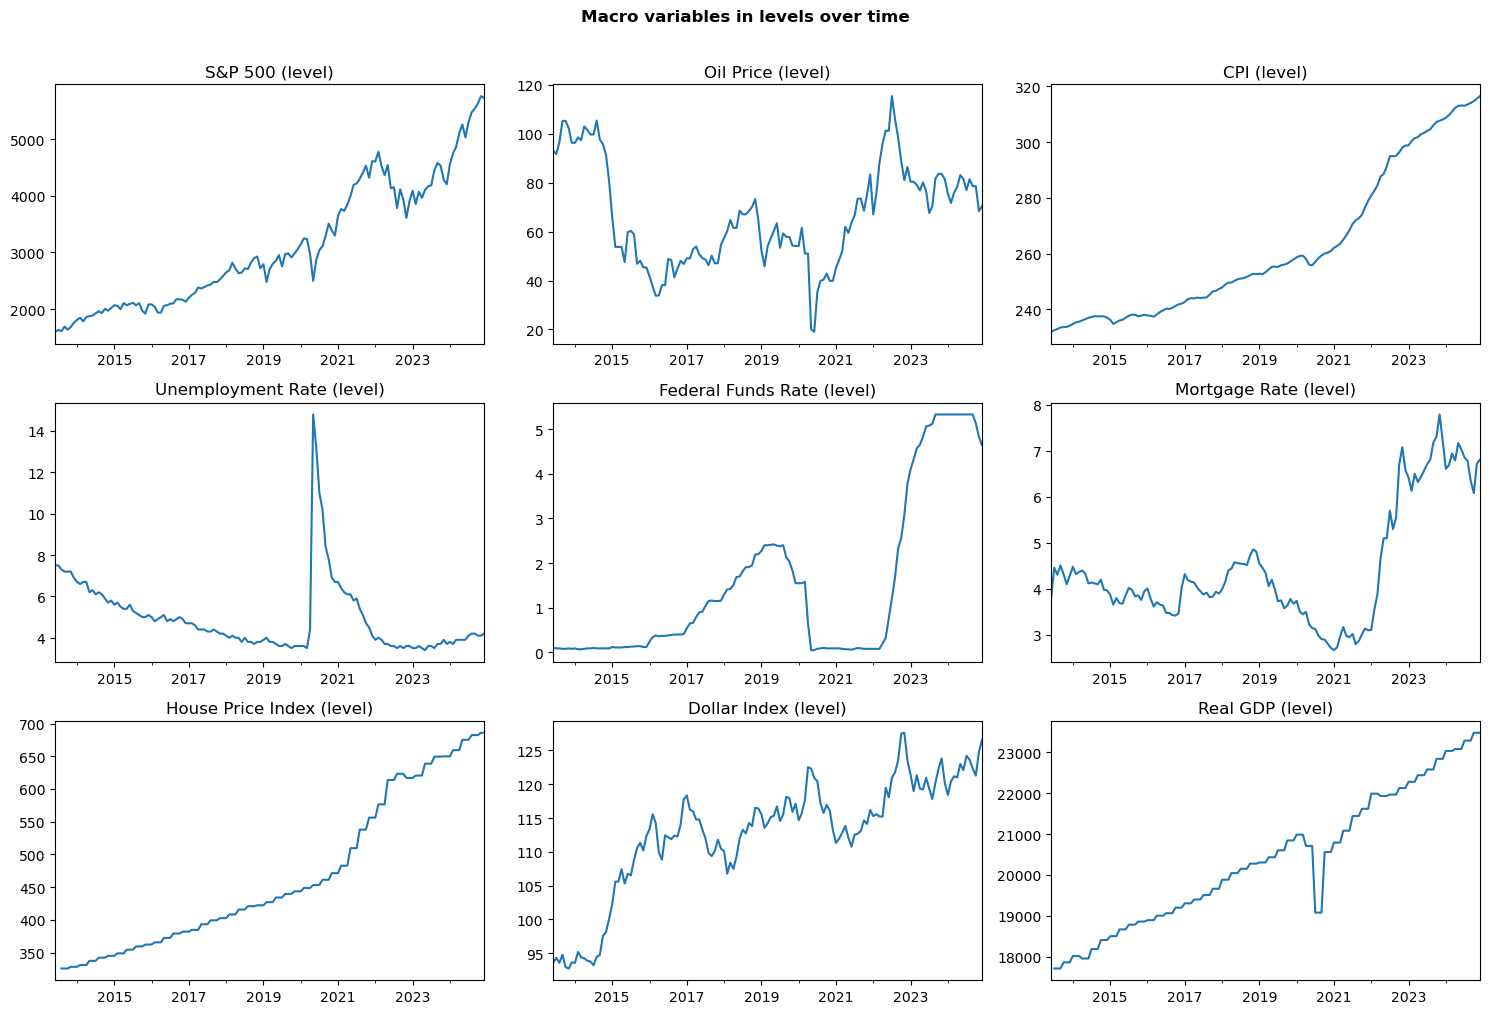

In [26]:
# plot
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, var in enumerate(macro_vars):
    df_levels[var].plot(ax=axes[i])
    axes[i].set_title(titles_levels[var])
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

plt.suptitle("Macro variables in levels over time", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

The plots showthe average year-month value of each macro variable over the sample period. Most notable is the sharp spike in unemployment in 2020 due to COVID-19, and the rapid rise in interest rates from 2022 onwards as the Fed tightened monetary policy. The S&P 500, CPI, and house prices all trend upward throughout, while the dollar index shows no clear long-run trend.

## 2. Changes in macro variables

In [27]:
# variable name
titles_changes = {
    "sp500_mom":    "S&P 500 (MoM %)",
    "oil_mom":      "Oil Price (MoM %)",
    "cpi_mom":      "CPI (MoM %)",
    "cpi_yoy":      "CPI (YoY %)",
    "unrate_mom":   "Unemployment (MoM diff)",
    "fedfunds_mom": "Fed Funds (MoM diff)",
    "mortgage_mom": "Mortgage Rate (MoM diff)",
    "hpi_mom":      "House Price Index (MoM %)",
    "hpi_yoy":      "House Price Index (YoY %)",
    "dollar_mom":   "Dollar Index (MoM %)",
    "gdp_qoq":      "Real GDP (QoQ %)",
    "gdp_yoy":      "Real GDP (YoY %)",
}

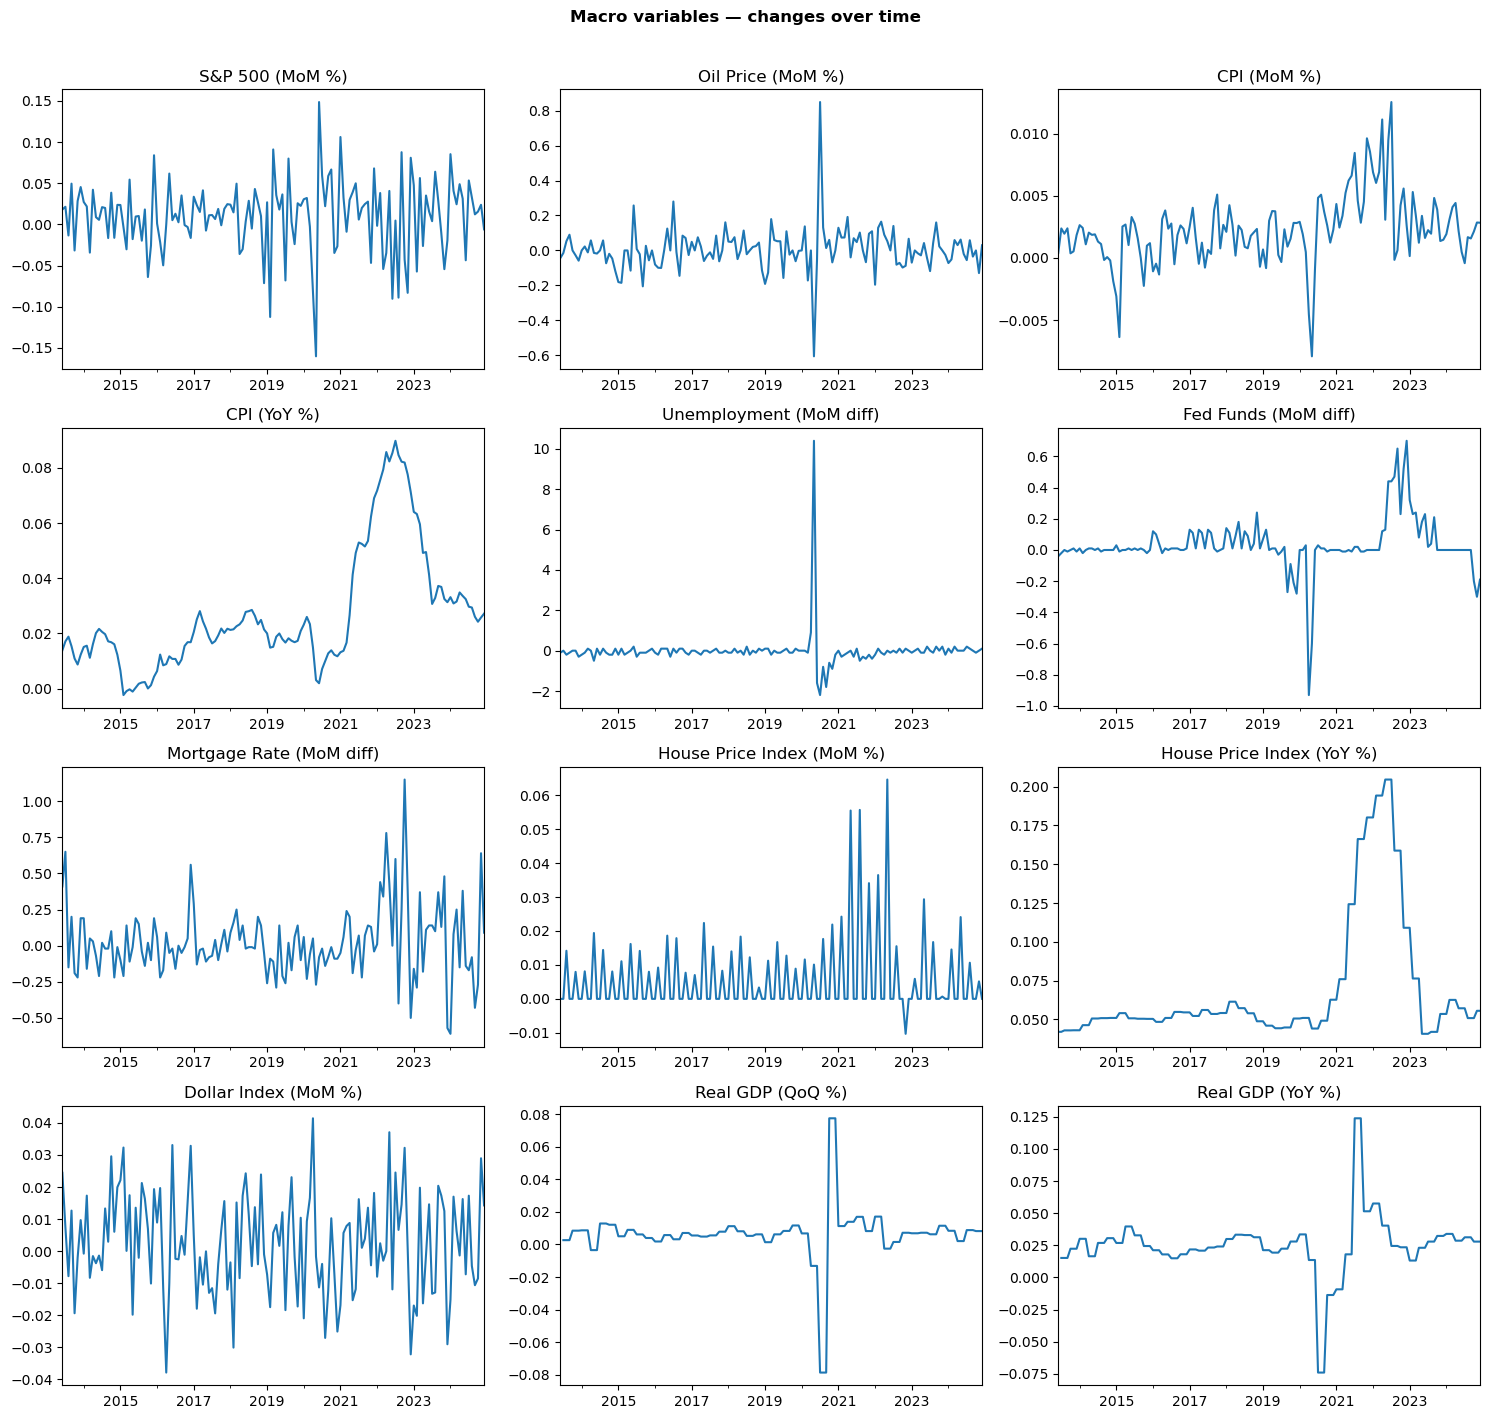

In [28]:
# plot
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()

for i, var in enumerate(macro_changes):
    df_changes[var].plot(ax=axes[i])
    axes[i].set_title(titles_changes[var])
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

plt.suptitle("Macro variables — changes over time", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

The change variables highlight the same key episodes more clearly. The 2020 COVID shock is visible across nearly all series we se that oil prices collapses, unemployment increases significantly, and GDP contract. Meanwhile the 2021–2022 inflation surge stands out in CPI YoY, peaking around 8–9%. The fed funds and mortgage rate changes capture the subsequent tightening cycle clearly. Outside these episodes many change variables fluctuate closely around zero.

## 3. Correlation between macro varaibles and expectation variables

In [29]:
expectation_vars = ["infl_1y", "house_price_change", "prob_unrate_up", "prob_stocks_up"]
macro_all = macro_vars + macro_changes

# table
for var in expectation_vars:
    corr = df[macro_all + [var]].corr()[var].drop(var)
    corr = corr.sort_values(key=abs, ascending=False)
    corr_table = corr.to_frame(name="Correlation")
    print(f"\nCorrelation with {var}:")
    display(corr_table.round(3))


Correlation with infl_1y:


,Correlation
hpi_yoy,0.127
cpi_yoy,0.113
cpi_mom,0.089
oil_lag,0.065
sp500_lag,0.057
hpi_lag,0.053
gdp_yoy,0.049
cpi_lag,0.047
fedfunds_mom,0.046
mortgage_mom,0.044



Correlation with house_price_change:


,Correlation
dollar_lag,-0.087
fedfunds_lag,-0.082
mortgage_lag,-0.076
gdp_yoy,0.071
cpi_mom,0.066
cpi_lag,-0.054
hpi_mom,0.050
gdp_qoq,0.049
hpi_lag,-0.048
hpi_yoy,0.046



Correlation with prob_unrate_up:


,Correlation
mortgage_lag,0.055
fedfunds_lag,0.045
unrate_lag,-0.032
fedfunds_mom,0.029
dollar_lag,0.026
cpi_lag,0.025
gdp_yoy,-0.025
hpi_lag,0.022
oil_lag,0.021
sp500_mom,-0.020



Correlation with prob_stocks_up:


,Correlation
unrate_lag,0.057
cpi_yoy,-0.054
fedfunds_mom,-0.054
cpi_lag,-0.049
mortgage_lag,-0.049
hpi_lag,-0.048
gdp_lag,-0.044
fedfunds_lag,-0.042
hpi_yoy,-0.038
sp500_lag,-0.038


For each of the four expectation variables we calculate the correlation to all macro variables. 
Correlations between macro variables and expectation variables are generally very small across all four targets, with no single variable exceeding 0.13. This suggests that aggregate macro conditions have limited direct explanatory power for individual household expectations.

The most notable patterns are that inflation expectations correlate most with housing and price-related variables (HPI YoY, CPI YoY), and house price expectations negatively correlated with interest rate levels, consistent with the idea that higher rates lowers housing market optimism. For prob_unrate_up and prob_stocks_up all correlations are below 0.06, suggesting macro variables are particularly weak predictors for these two expectations.

The results are expected since macro variables take the same value for all respondents in a given month, they cannot explain variation in expectations across individuals within the same month.

# Part 5 - Predicting continuous expectation variables

We split the data into a training sample (observations before 2024) and a test 
sample (2024). We then estimate three regression models; Linear Regression, 
Ridge, and Lasso for each of the four continuous expectation variables. Each 
model is first estimated using only macro/finance variables, then re-estimated 
adding individual-level characteristics. Models are evaluated using RMSE and R² 
on the test sample.

Linear Regression has no hyperparameters and requires no tuning. Ridge and Lasso 
both have a penalty parameter alpha that controls regularization strength, which 
is selected via 5-fold cross-validation. Feature scaling is required for all 
three models and is implemented using StandardScaler inside a Pipeline.

In [30]:
# saving results
results_reg = []
results_clf = []

## 1. Split data

In [31]:
# split data
df_train = df[df["date"] < "2024-01-01"]
df_test  = df[(df["date"] >= "2024-01-01") & (df["date"] <= "2024-12-31")]

print(f"Training observations: {len(df_train)}")
print(f"Test observations: {len(df_test)}")

Training observations: 147874
Test observations: 11756


## 2. Define variables

In [32]:
# target and feature variables
target_vars  = ["infl_1y", "house_price_change", "prob_unrate_up", "prob_stocks_up"]

X_macro = [
    "sp500_lag", "sp500_mom",
    "oil_lag", "oil_mom",
    "cpi_lag", "cpi_mom", "cpi_yoy",
    "unrate_lag", "unrate_mom",
    "fedfunds_lag", "fedfunds_mom",
    "mortgage_lag", "mortgage_mom",
    "hpi_lag", "hpi_mom", "hpi_yoy",
    "dollar_lag", "dollar_mom",
    "gdp_lag", "gdp_qoq", "gdp_yoy"
]

X_individual = ["age_init", "educ", "hh_inc_bin", "female"]
alphas       = np.logspace(-3, 3, 20)

feature_sets = [("Macro only", X_macro), ("Macro + Individual", X_macro + X_individual)]

## 3. Linear regression

In [33]:
# linear regression
for y_var in target_vars:
    for feature_set, X_vars in [("Macro only", X_macro), ("Macro + Individual", X_macro + X_individual)]:
        train = df_train[X_vars + [y_var]].dropna()
        test  = df_test[X_vars  + [y_var]].dropna()

        X_train, y_train = train[X_vars], train[y_var]
        X_test,  y_test  = test[X_vars],  test[y_var]

        pipe = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        results_reg.append({
            "Target":    y_var,
            "Model":     "Linear Regression",
            "Features":  feature_set,
            "Test RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
            "Test R2":   round(r2_score(y_test, y_pred), 3),
        })

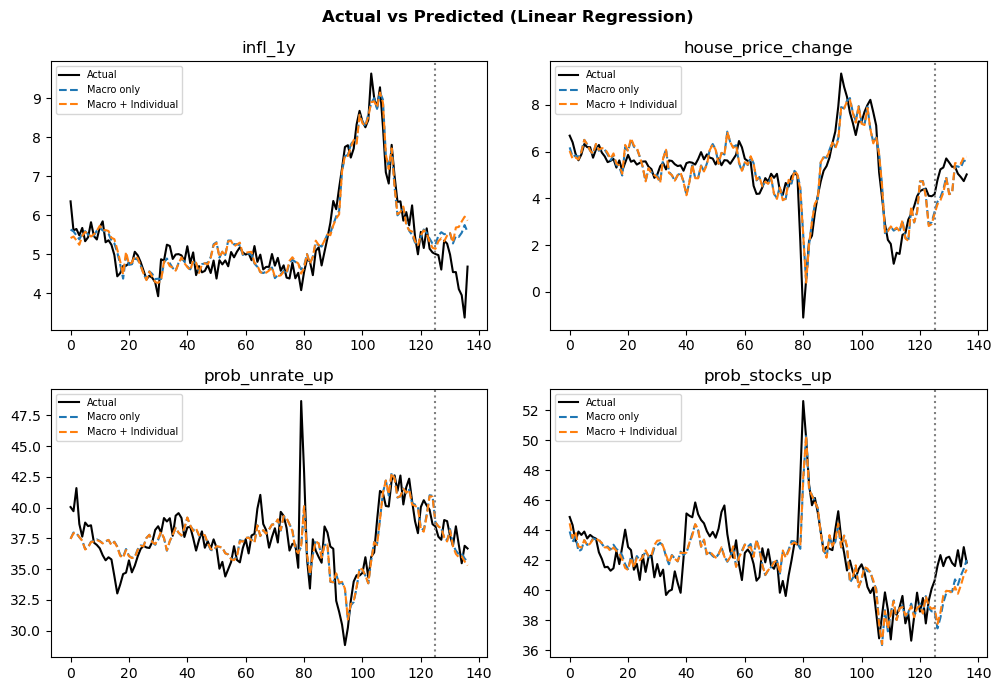

In [34]:
# actual vs predicted

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
fig.suptitle("Actual vs Predicted (Linear Regression)", fontweight="bold")
axes = axes.flatten()

for i, y_var in enumerate(target_vars):

    #  Macro only 
    X_vars_macro = X_macro

    train_m = df_train[X_vars_macro + [y_var]].dropna().copy()
    test_m = df_test[X_vars_macro + [y_var]].dropna().copy()

    pipe_m = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])

    pipe_m.fit(train_m[X_vars_macro], train_m[y_var])
    train_m["pred"] = pipe_m.predict(train_m[X_vars_macro])
    test_m["pred"] = pipe_m.predict(test_m[X_vars_macro])

    #  Macro + Individual 
    X_vars_full = X_macro + X_individual

    train_f = df_train[X_vars_full + [y_var]].dropna().copy()
    test_f = df_test[X_vars_full + [y_var]].dropna().copy()

    pipe_f = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])

    pipe_f.fit(train_f[X_vars_full], train_f[y_var])
    train_f["pred"] = pipe_f.predict(train_f[X_vars_full])
    test_f["pred"] = pipe_f.predict(test_f[X_vars_full])

    #  aggregate 
    train_m["year_month"] = df_train.loc[train_m.index, "year_month"]
    test_m["year_month"] = df_test.loc[test_m.index, "year_month"]

    train_f["year_month"] = df_train.loc[train_f.index, "year_month"]
    test_f["year_month"] = df_test.loc[test_f.index, "year_month"]

    tr_m = train_m.groupby("year_month")[[y_var, "pred"]].mean()
    te_m = test_m.groupby("year_month")[[y_var, "pred"]].mean()

    tr_f = train_f.groupby("year_month")[[y_var, "pred"]].mean()
    te_f = test_f.groupby("year_month")[[y_var, "pred"]].mean()

    actual = pd.concat([tr_m[y_var], te_m[y_var]])
    pred_m = pd.concat([tr_m["pred"], te_m["pred"]])
    pred_f = pd.concat([tr_f["pred"], te_f["pred"]])

    x = range(len(actual))
    split = len(tr_m)

    #  plot 
    axes[i].plot(x, actual, label="Actual", color="black")
    axes[i].plot(x, pred_m, label="Macro only", linestyle="--")
    axes[i].plot(x, pred_f, label="Macro + Individual", linestyle="--")

    axes[i].axvline(x=split, color="gray", linestyle=":")
    axes[i].set_title(y_var)
    axes[i].legend(fontsize=7)

plt.tight_layout()
plt.show()

The linear regression captures the broad trends in all four expectation variables, particularly the inflation surge in 2021–2022 and its subsequent decline. Adding individual variables (Macro + Individual) leads to a modest improvement, most visible for prob_stocks_up. Overall, the model tracks average expectations reasonably well in the training period but struggles in the test period, where predictions diverge from actual values.

## 4. Rigid regressions

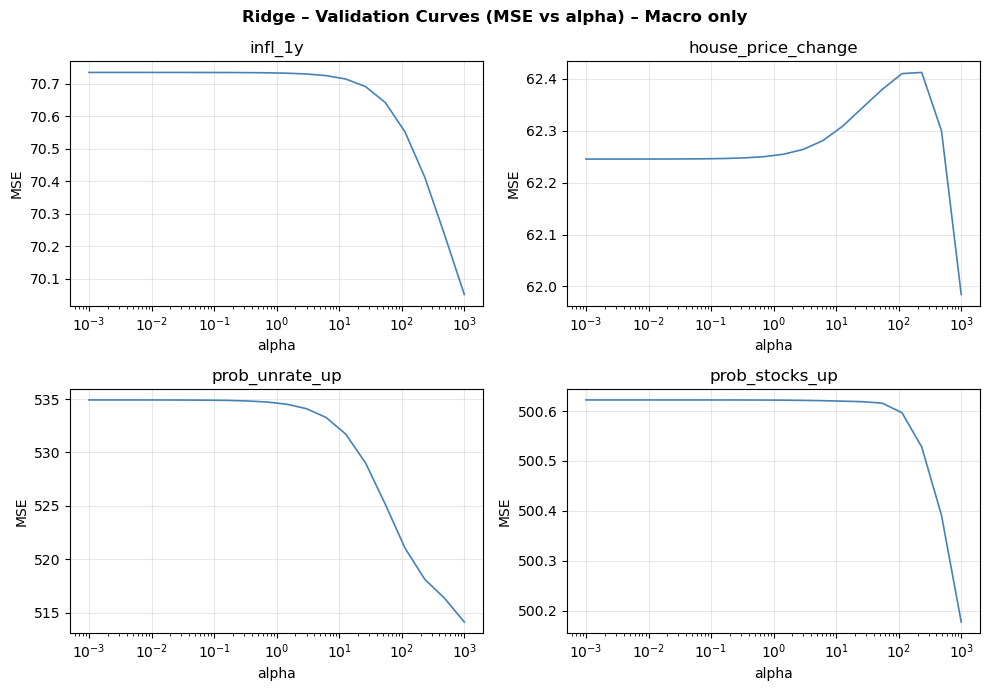

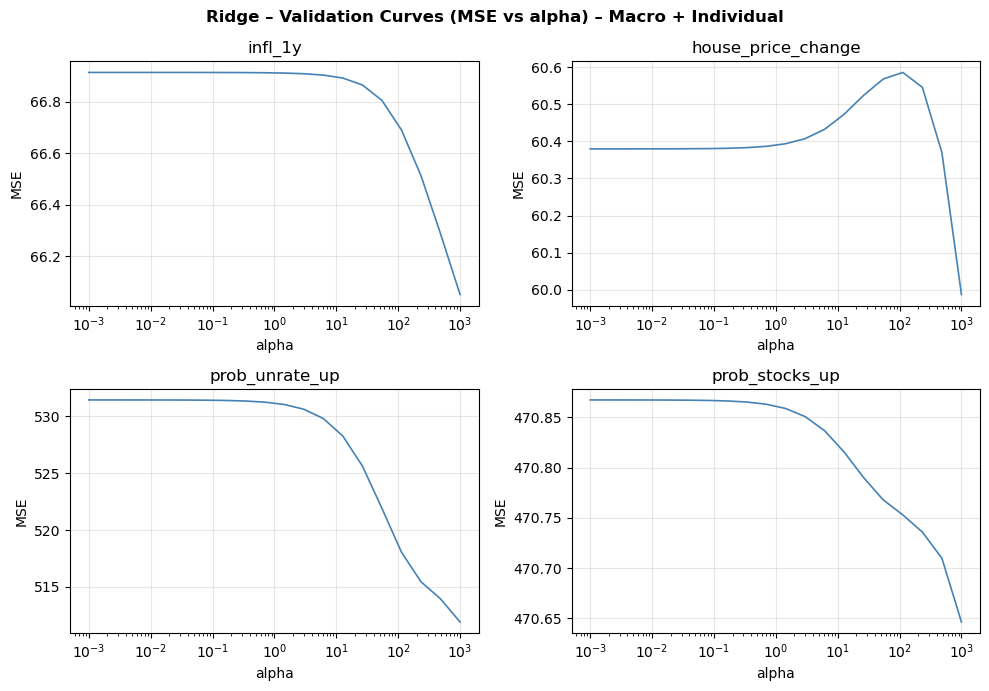

In [35]:
# validation curve
feature_sets = [("Macro only", X_macro), ("Macro + Individual", X_macro + X_individual)]

for feature_set, X_vars in feature_sets:
    fig, axes = plt.subplots(2, 2, figsize=(10, 7))
    fig.suptitle(f"Ridge – Validation Curves (MSE vs alpha) – {feature_set}", fontweight="bold")
    axes = axes.flatten()

    for i, y_var in enumerate(target_vars):
        train = df_train[X_vars + [y_var]].dropna()
        X_sc  = StandardScaler().fit_transform(train[X_vars])
        y     = train[y_var]

        _, val_scores = validation_curve(
            Ridge(), X_sc, y,
            param_name="alpha", param_range=alphas,
            scoring="neg_mean_squared_error", cv=5
        )

        axes[i].plot(alphas, -val_scores.mean(axis=1), color="steelblue", linewidth=1.2)
        axes[i].set_xscale("log")
        axes[i].set_title(y_var)
        axes[i].set_xlabel("alpha")
        axes[i].set_ylabel("MSE")
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

The validation curves show that MSE decreases as alpha increases for all four targets, with the lowest MSE found at high alpha values. This suggests that regularization is beneficial, likely because the macro predictors are correlated with each other. At very low alpha values, Ridge behaves like OLS and MSE is higher. The smooth decrease in MSE confirms that shrinking coefficients improves out-of-sample consistency.

In [36]:
# Ridge loop
for y_var in target_vars:
    for feature_set, X_vars in [("Macro only", X_macro), ("Macro + Individual", X_macro + X_individual)]:

        train = df_train[X_vars + [y_var]].dropna()
        test  = df_test[X_vars + [y_var]].dropna()

        X_train, y_train = train[X_vars], train[y_var]
        X_test,  y_test  = test[X_vars],  test[y_var]

        pipe = Pipeline([("scaler", StandardScaler()), ("model", RidgeCV(alphas=alphas, cv=5))])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        results_reg.append({
            "Target":    y_var,
            "Model":     "Ridge",
            "Features":  feature_set,
            "Test RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
            "Test R2":   round(r2_score(y_test, y_pred), 3),
        })

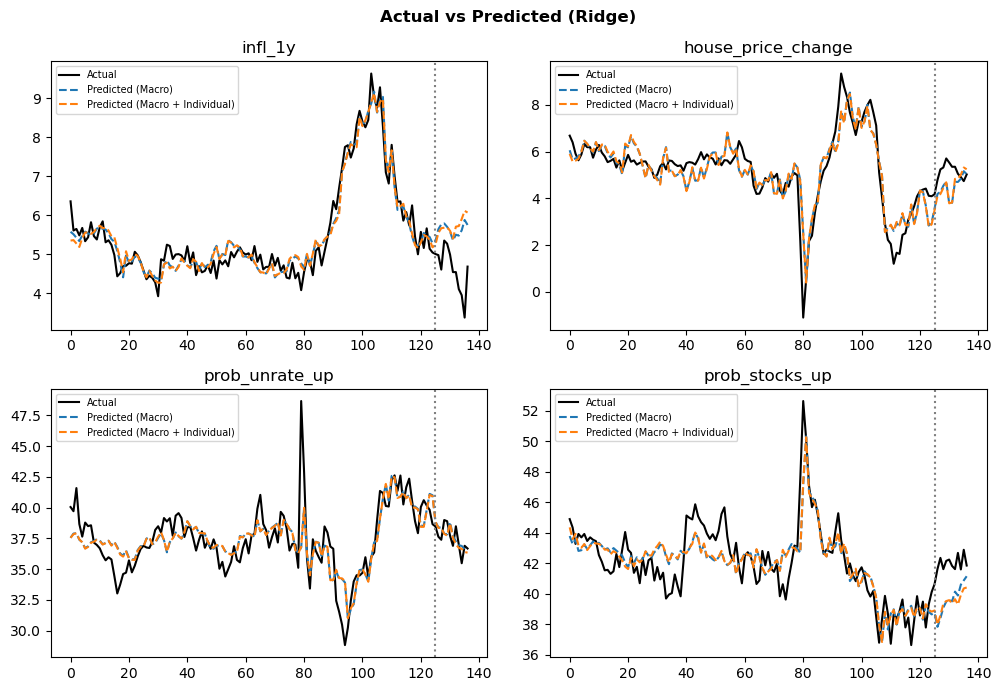

In [37]:
# Actual vs Predicted (Ridge)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
fig.suptitle("Actual vs Predicted (Ridge)", fontweight="bold")
axes = axes.flatten()

for i, y_var in enumerate(target_vars):

    # Macro only
    X_m = X_macro
    train_m = df_train[X_m + [y_var]].dropna().copy()
    test_m = df_test[X_m + [y_var]].dropna().copy()

    model_m = Pipeline([
        ("scaler", StandardScaler()),
        ("model", RidgeCV(alphas=alphas, cv=5))
    ])
    model_m.fit(train_m[X_m], train_m[y_var])

    train_m["pred"] = model_m.predict(train_m[X_m])
    test_m["pred"] = model_m.predict(test_m[X_m])

    # Macro + Individual
    X_f = X_macro + X_individual
    train_f = df_train[X_f + [y_var]].dropna().copy()
    test_f = df_test[X_f + [y_var]].dropna().copy()

    model_f = Pipeline([
        ("scaler", StandardScaler()),
        ("model", RidgeCV(alphas=alphas, cv=5))
    ])
    model_f.fit(train_f[X_f], train_f[y_var])

    train_f["pred"] = model_f.predict(train_f[X_f])
    test_f["pred"] = model_f.predict(test_f[X_f])

    # Aggregate
    train_m["year_month"] = df_train.loc[train_m.index, "year_month"]
    test_m["year_month"] = df_test.loc[test_m.index, "year_month"]

    train_f["year_month"] = df_train.loc[train_f.index, "year_month"]
    test_f["year_month"] = df_test.loc[test_f.index, "year_month"]

    tr_m = train_m.groupby("year_month")[[y_var, "pred"]].mean()
    te_m = test_m.groupby("year_month")[[y_var, "pred"]].mean()

    tr_f = train_f.groupby("year_month")[[y_var, "pred"]].mean()
    te_f = test_f.groupby("year_month")[[y_var, "pred"]].mean()

    actual = pd.concat([tr_m[y_var], te_m[y_var]])
    pred_m = pd.concat([tr_m["pred"], te_m["pred"]])
    pred_f = pd.concat([tr_f["pred"], te_f["pred"]])

    x = range(len(actual))
    split = len(tr_m)

    axes[i].plot(x, actual, label="Actual", color="black")
    axes[i].plot(x, pred_m, "--", label="Predicted (Macro)")
    axes[i].plot(x, pred_f, "--", label="Predicted (Macro + Individual)")
    axes[i].axvline(split, color="gray", linestyle=":")

    axes[i].set_title(y_var)
    axes[i].legend(fontsize=7)

plt.tight_layout()
plt.show()

Ridge predictions are very similar to those of linear regression, which is expected given that Ridge shrinks but does not eliminate coefficients. The ridge regression has a regularization parameter alpha that shrinks large coefficients. This is to help reduce overfitting, which is relevant when they predictors are highly correlated. Due to ridge regression is dependent on the scale of the variables, we standardize before fitting the model. To find the optimal value of alpha we plot validation curves to show the MSE varies with alpha. The validation curves show that for alpha values close to zero the model behaves similar to OLS, with high MSE. As the alpha increase the MSE decreases for all the target variables, which demonstrates that the regularization does improve the out of sample performance.  For all the expectation variables, the lowest MSE is observed at high alpha values. This indicate that regularization is helpful, most likely due to the macroeconomic predictors being correlated. The shape of the curve having a smooth decrease in MSE shows that the model consistency improves when the alpha increases. 

## 5. Lasso regression

In [38]:
# loop
for y_var in target_vars:
    for feature_set, X_vars in [("Macro only", X_macro), ("Macro + Individual", X_macro + X_individual)]:

        train = df_train[X_vars + [y_var]].dropna()
        test  = df_test[X_vars + [y_var]].dropna()

        X_train, y_train = train[X_vars], train[y_var]
        X_test,  y_test  = test[X_vars],  test[y_var]

        pipe = Pipeline([("scaler", StandardScaler()), ("model", LassoCV(cv=5, max_iter=10000))])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        results_reg.append({
            "Target":    y_var,
            "Model":     "Lasso",
            "Features":  feature_set,
            "Test RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred)), 3),
            "Test R2":   round(r2_score(y_test, y_pred), 3),
        })

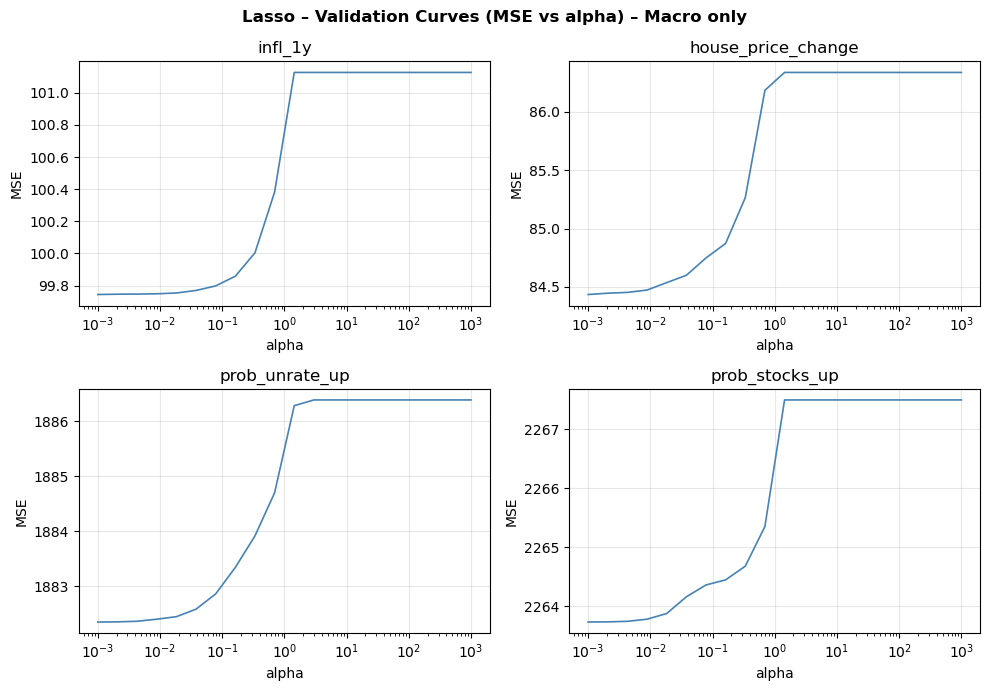

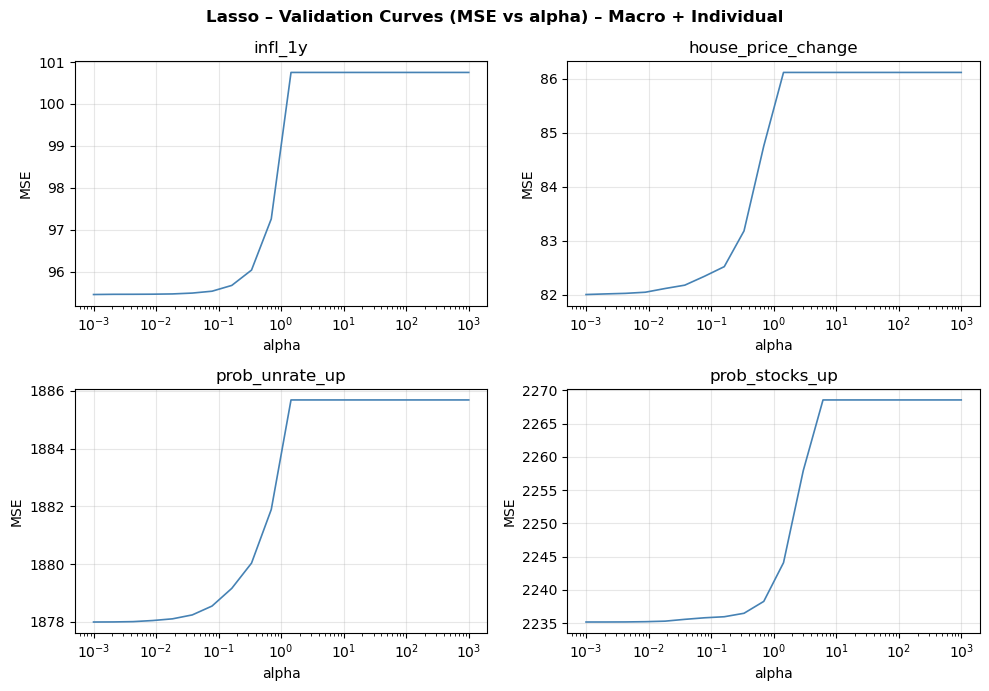

In [39]:
# Validation curves for Lasso 
for feature_set, X_vars in feature_sets:
    fig, axes = plt.subplots(2, 2, figsize=(10, 7))
    fig.suptitle(f"Lasso – Validation Curves (MSE vs alpha) – {feature_set}", fontweight="bold")
    axes = axes.flatten()

    for i, y_var in enumerate(target_vars):
        train = df_train[X_vars + [y_var]].dropna()
        X_sc  = StandardScaler().fit_transform(train[X_vars])
        y     = train[y_var].values

        alphas_path, coefs, _ = lasso_path(X_sc, y, alphas=alphas, max_iter=10000)

        mse = []
        for coef in coefs.T:
            y_pred = X_sc @ coef
            mse.append(mean_squared_error(y, y_pred))

        axes[i].plot(alphas_path, mse, color="steelblue", linewidth=1.2)
        axes[i].set_xscale("log")
        axes[i].set_title(y_var)
        axes[i].set_xlabel("alpha")
        axes[i].set_ylabel("MSE")
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

The Lasso validation curves show the opposite pattern to Ridge: MSE is lowest at very small alpha values and increases sharply as alpha grows. This indicates that Lasso variable selection, setting coefficients to zero, removes useful information from the model. The optimal alpha being close to zero suggests that most macro variables contribute meaningfully to predictions, and that sparse 
solutions are not appropriate here. Lasso therefore behaves similarly to OLS in this setting.

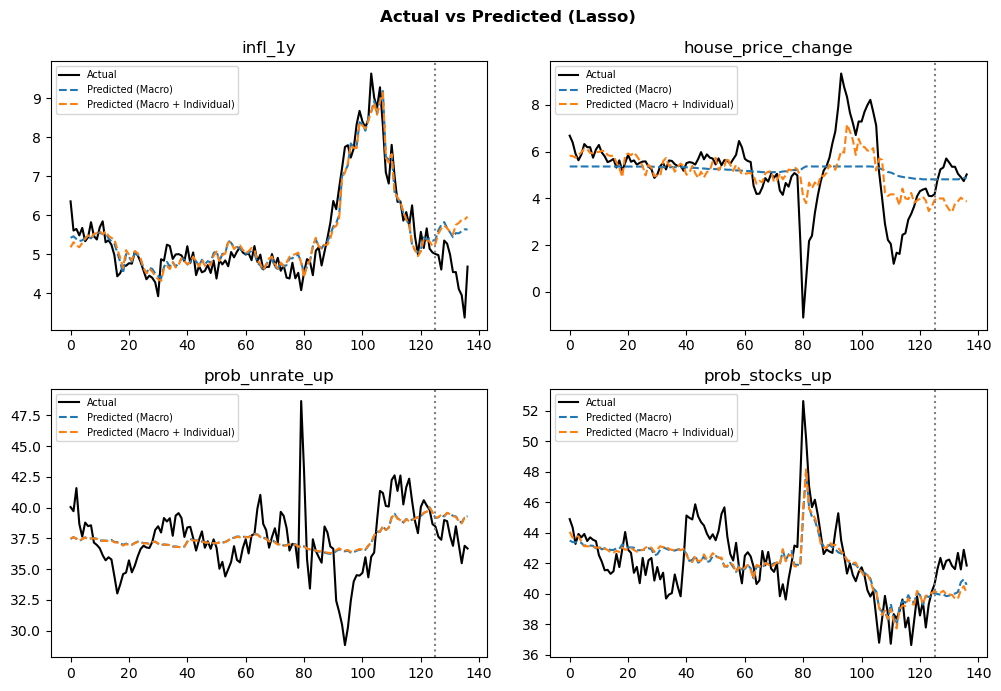

In [40]:
# Actual vs Predicted 
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
fig.suptitle("Actual vs Predicted (Lasso)", fontweight="bold")
axes = axes.flatten()

for i, y_var in enumerate(target_vars):

    # Macro only
    X_m = X_macro
    train_m = df_train[X_m + [y_var]].dropna().copy()
    test_m = df_test[X_m + [y_var]].dropna().copy()

    model_m = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LassoCV(cv=5, max_iter=10000))
    ])
    model_m.fit(train_m[X_m], train_m[y_var])

    train_m["pred"] = model_m.predict(train_m[X_m])
    test_m["pred"] = model_m.predict(test_m[X_m])

    # Macro + Individual
    X_f = X_macro + X_individual
    train_f = df_train[X_f + [y_var]].dropna().copy()
    test_f = df_test[X_f + [y_var]].dropna().copy()

    model_f = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LassoCV(cv=5, max_iter=10000))
    ])
    model_f.fit(train_f[X_f], train_f[y_var])

    train_f["pred"] = model_f.predict(train_f[X_f])
    test_f["pred"] = model_f.predict(test_f[X_f])

    # Aggregate
    train_m["year_month"] = df_train.loc[train_m.index, "year_month"]
    test_m["year_month"] = df_test.loc[test_m.index, "year_month"]

    train_f["year_month"] = df_train.loc[train_f.index, "year_month"]
    test_f["year_month"] = df_test.loc[test_f.index, "year_month"]

    tr_m = train_m.groupby("year_month")[[y_var, "pred"]].mean()
    te_m = test_m.groupby("year_month")[[y_var, "pred"]].mean()

    tr_f = train_f.groupby("year_month")[[y_var, "pred"]].mean()
    te_f = test_f.groupby("year_month")[[y_var, "pred"]].mean()

    actual = pd.concat([tr_m[y_var], te_m[y_var]])
    pred_m = pd.concat([tr_m["pred"], te_m["pred"]])
    pred_f = pd.concat([tr_f["pred"], te_f["pred"]])

    x = range(len(actual))
    split = len(tr_m)

    axes[i].plot(x, actual, label="Actual", color="black")
    axes[i].plot(x, pred_m, "--", label="Predicted (Macro)")
    axes[i].plot(x, pred_f, "--", label="Predicted (Macro + Individual)")
    axes[i].axvline(split, color="gray", linestyle=":")

    axes[i].set_title(y_var)
    axes[i].legend(fontsize=7)

plt.tight_layout()
plt.show()

Lasso regression introduces an L1 penalty controlled by the hypermeter alpha, which shrinks coefficients and can set them equal to zero. This means that Lasso can perform automatic variable selection in addition to reducing overfitting. Same as with Ridge, scaling is required and is implemented using a standardizing step. We plot validation curves to see how the MSE varies with penalty strength. The validation curve shows that the lowest MSE is found with very small values of alpha for all the target variables. As the alpha increases the MSE rises a lot, which also decreases the model performance. This demonstrates that setting the coefficients to zero removes useful information from the model. The optimal alpha is close to zero, suggesting that a model close to OLS has the best performance. Overall, this suggest that the expectation variables in the dataset are better explained by more macroeconomic variables rather than selecting a few. 

In [41]:
# save data
pd.DataFrame(results_reg)

,Target,Model,Features,Test RMSE,Test R2
0,infl_1y,Linear Regression,Macro only,9.265,-0.010
1,infl_1y,Linear Regression,Macro + Individual,9.080,0.032
2,house_price_change,Linear Regression,Macro only,8.480,-0.008
3,house_price_change,Linear Regression,Macro + Individual,8.343,0.023
4,prob_unrate_up,Linear Regression,Macro only,22.319,-0.000
5,prob_unrate_up,Linear Regression,Macro + Individual,22.044,0.023
6,prob_stocks_up,Linear Regression,Macro only,23.081,-0.010
7,prob_stocks_up,Linear Regression,Macro + Individual,21.988,0.083
8,infl_1y,Ridge,Macro only,9.276,-0.012
9,infl_1y,Ridge,Macro + Individual,9.093,0.029


Across all models and targets, Test R² values are close to zero or slightly negative, indicating that the models have limited out-of-sample predictive power for individual-level expectations. Adding individual variables consistently reduces RMSE and improves R² slightly, but the gains are small. All three models perform similarly, suggesting that the limiting factor is the feature set rather than the choice of model

# Part 6 - Predicting binary optimism variables

In this part we predict three binary optimism indicators using logistic regression. Since roughly 60% of respondents are optimists, a naive majority classifier achieves about 60% accuracy, we therefore report balanced accuracy alongside standard accuracy to account for class imbalance. Models are estimated for both macro-only and macro + individual feature sets.

## 1. Defining binary target variables

In [42]:
# features
target_vars_clf = ["optimist_unrate", "optimist_stocks", "optimist_house_price"]
results_clf     = []

X_macro = [
    "sp500_lag", "sp500_mom",
    "oil_lag", "oil_mom",
    "cpi_lag", "cpi_mom", "cpi_yoy",
    "unrate_lag", "unrate_mom",
    "fedfunds_lag", "fedfunds_mom",
    "mortgage_lag", "mortgage_mom",
    "hpi_lag", "hpi_mom", "hpi_yoy",
    "dollar_lag", "dollar_mom",
    "gdp_lag", "gdp_qoq", "gdp_yoy"
]

X_individual = ["age_init", "educ", "hh_inc_bin", "female"]

In [43]:
warnings.filterwarnings("ignore")


## 2. Logistic regression (CV)

In [44]:
for y_var in target_vars_clf:
    for feature_set, X_vars in feature_sets:

        train = df_train[X_vars + [y_var]].dropna()
        test  = df_test[X_vars + [y_var]].dropna()

        X_train, y_train = train[X_vars], train[y_var]
        X_test, y_test   = test[X_vars], test[y_var]

        pipe_logit = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegressionCV(
                cv=5,
                class_weight="balanced",
                max_iter=1000
            ))
        ])

        pipe_logit.fit(X_train, y_train)

        best_C = pipe_logit.named_steps["model"].C_[0]

        # Predictions
        y_train_pred = pipe_logit.predict(X_train)
        y_test_pred  = pipe_logit.predict(X_test)

        # Metrics (train + test)
        results_clf.append({
            "Target": y_var,
            "Features": feature_set,
            "Model": "Logistic",
            "best c": best_C,
            "Train Acc": accuracy_score(y_train, y_train_pred),
            "Test Acc": accuracy_score(y_test, y_test_pred),
            "Balanced Acc": balanced_accuracy_score(y_test, y_test_pred),
            "Precision": precision_score(y_test, y_test_pred, zero_division=0),
            "Recall": recall_score(y_test, y_test_pred, zero_division=0),
            "F1": f1_score(y_test, y_test_pred, zero_division=0)
        })

## 3. Random forest

In [45]:
# random forest
for y_var in target_vars_clf:
    for feature_set, X_vars in feature_sets:

        train = df_train[X_vars + [y_var]].dropna()
        test  = df_test[X_vars + [y_var]].dropna()

        X_train, y_train = train[X_vars], train[y_var]
        X_test, y_test   = test[X_vars], test[y_var]

        rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=123,
        n_jobs=-1
    )

        rf.fit(X_train, y_train)

        y_train_pred = rf.predict(X_train)
        y_test_pred  = rf.predict(X_test)

        results_clf.append({
            "Target": y_var,
            "Features": feature_set,
            "Model": "Random forest",
            "Best C": best_C,
            "Train Acc": accuracy_score(y_train, y_train_pred),
            "Test Acc": accuracy_score(y_test, y_test_pred),
            "Balanced Acc": balanced_accuracy_score(y_test, y_test_pred),
            "Precision": precision_score(y_test, y_test_pred, zero_division=0),
            "Recall": recall_score(y_test, y_test_pred, zero_division=0),
            "F1": f1_score(y_test, y_test_pred, zero_division=0)
        })

## 4. Plot optimists amount

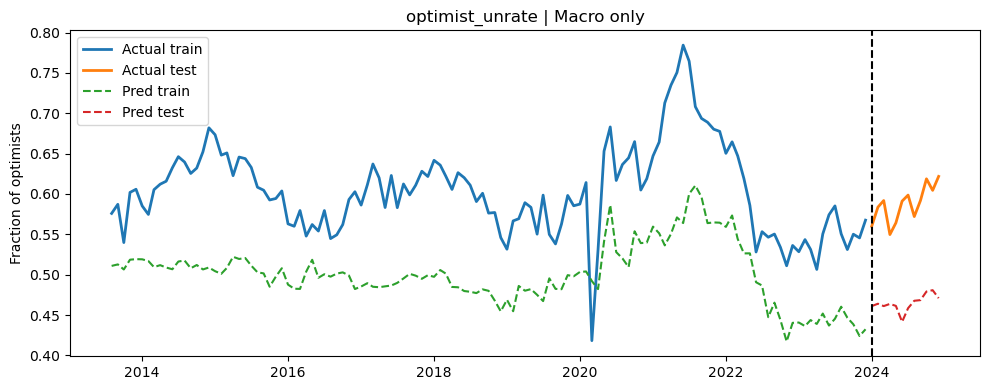

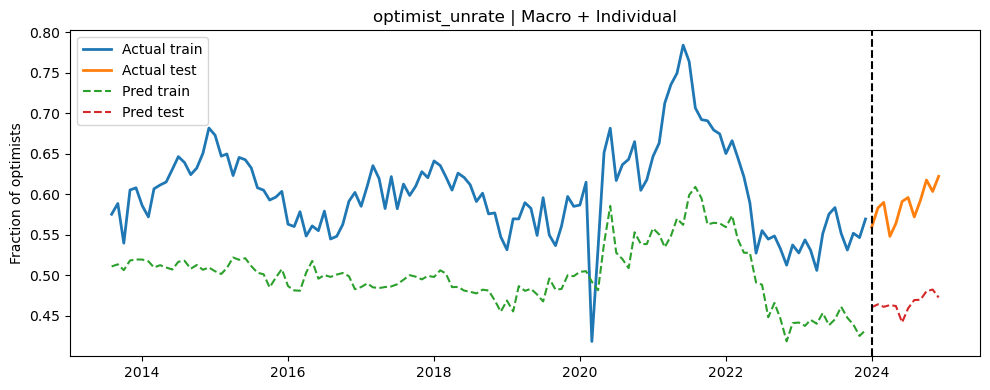

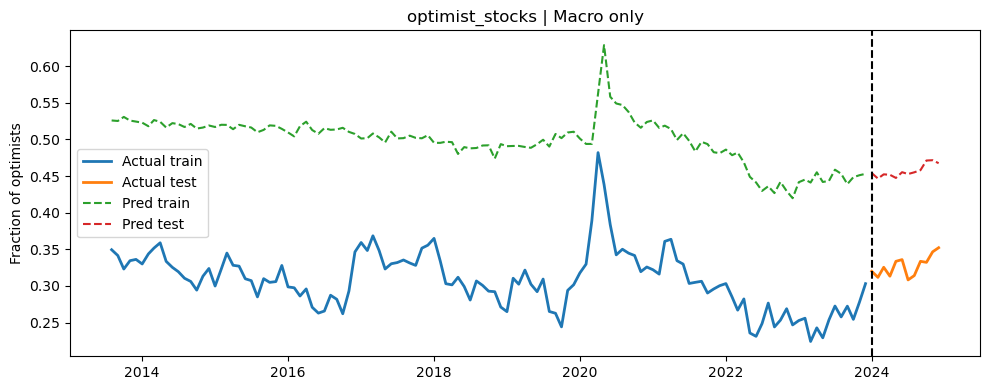

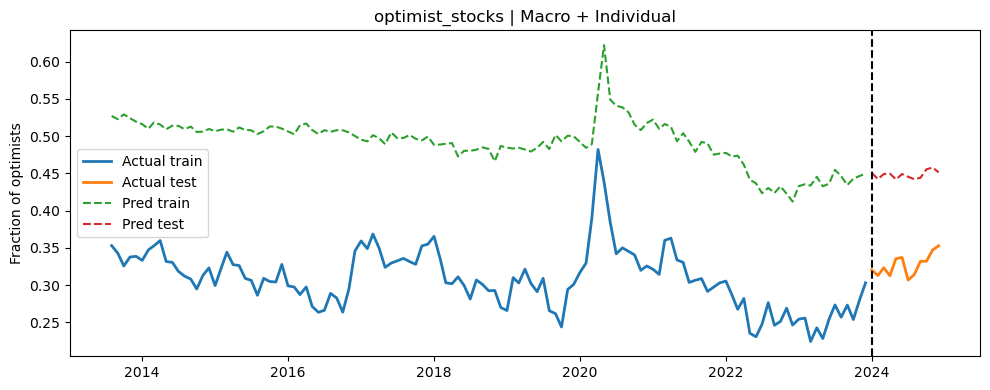

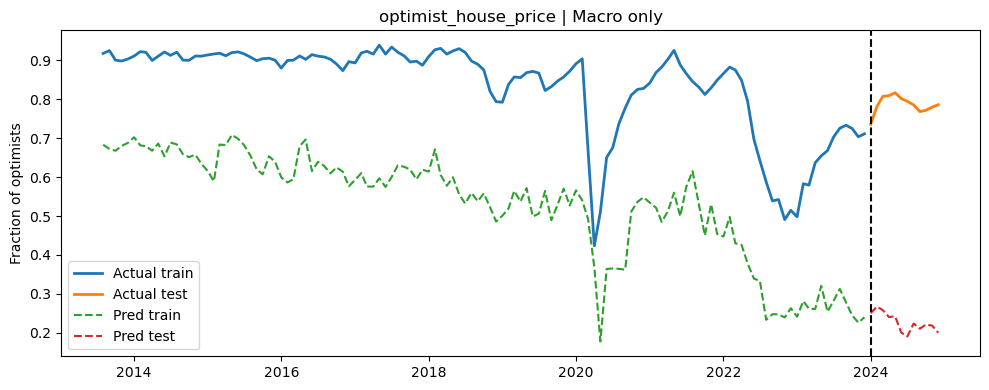

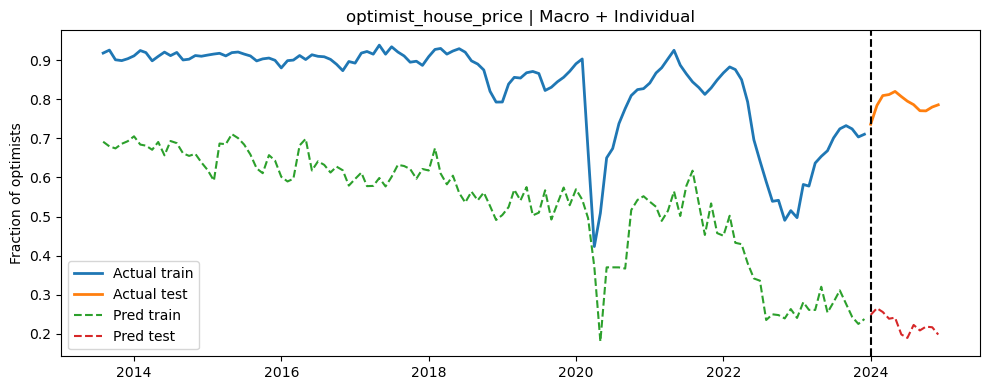

In [46]:
# plot
for y_var in target_vars_clf:
    for feature_set, X_vars in feature_sets:

        # --- prepare data ---
        train = df_train[X_vars + [y_var, "year_month"]].dropna().copy()
        test  = df_test[X_vars + [y_var, "year_month"]].dropna().copy()

        train = train.sort_values("year_month")
        test  = test.sort_values("year_month")

        X_train, y_train = train[X_vars], train[y_var]
        X_test, y_test   = test[X_vars], test[y_var]

        # --- fit model (logistic) ---
        pipe_logit.fit(X_train, y_train)

        # --- predictions (probabilities) ---
        train_pred = pipe_logit.predict_proba(X_train)[:,1]
        test_pred  = pipe_logit.predict_proba(X_test)[:,1]

        # --- fix date format ---
        train_dates = train["year_month"].dt.to_timestamp()
        test_dates  = test["year_month"].dt.to_timestamp()

        # --- create dataframe for aggregation ---
        df_plot_train = pd.DataFrame({
            "date": train_dates,
            "actual": y_train,
            "pred": train_pred
        })

        df_plot_test = pd.DataFrame({
            "date": test_dates,
            "actual": y_test,
            "pred": test_pred
        })

        # --- aggregate to fraction (VERY IMPORTANT) ---
        monthly_train = df_plot_train.groupby("date").mean()
        monthly_test  = df_plot_test.groupby("date").mean()

        # --- plot ---
        plt.figure(figsize=(10,4))

        # actual (fraction)
        plt.plot(monthly_train.index, monthly_train["actual"], label="Actual train", linewidth=2)
        plt.plot(monthly_test.index, monthly_test["actual"], label="Actual test", linewidth=2)

        # predicted (fraction)
        plt.plot(monthly_train.index, monthly_train["pred"], linestyle="--", label="Pred train")
        plt.plot(monthly_test.index, monthly_test["pred"], linestyle="--", label="Pred test")

        # train/test split
        plt.axvline(pd.Timestamp("2024-01-01"), linestyle="--", color="black")

        plt.title(f"{y_var} | {feature_set}")
        plt.ylabel("Fraction of optimists")
        plt.legend()
        plt.tight_layout()
        plt.show()

The logistic regression captures some broad trends but systematically underpredicts the actual share of optimists, particularly for 
optimist_unrate and optimist_house_price. The predicted fraction moves close to 0.50 across most of the sample, reflecting the limited 
signal in the macro variables. Adding individual variables improves tracking for optimist_stocks and optimist_unrate, but has little 
effect on optimist_house_price.

## 4. Result table

In [47]:
results_df = pd.DataFrame(results_clf)
results_df

,Target,Features,Model,best c,Train Acc,Test Acc,Balanced Acc,Precision,Recall,F1,Best C
0,optimist_unrate,Macro only,Logistic,0.0001,0.530543,0.413406,0.500000,0.000000,0.000000,0.000000,NaN
1,optimist_unrate,Macro + Individual,Logistic,0.0001,0.532332,0.450374,0.521696,0.703846,0.107331,0.186260,NaN
2,optimist_stocks,Macro only,Logistic,0.0001,0.488131,0.673273,0.500000,0.000000,0.000000,0.000000,NaN
3,optimist_stocks,Macro + Individual,Logistic,0.0001,0.585387,0.666237,0.612847,0.488242,0.458947,0.473142,NaN
4,optimist_house_price,Macro only,Logistic,0.0001,0.726004,0.213423,0.500000,0.000000,0.000000,0.000000,NaN
5,optimist_house_price,Macro + Individual,Logistic,0.0001,0.719606,0.211567,0.500000,0.000000,0.000000,0.000000,NaN
6,optimist_unrate,Macro only,Random forest,NaN,0.604433,0.586594,0.500000,0.586594,1.000000,0.739438,0.0001
7,optimist_unrate,Macro + Individual,Random forest,NaN,0.611393,0.598522,0.527336,0.600505,0.940909,0.733120,0.0001
8,optimist_stocks,Macro only,Random forest,NaN,0.691700,0.673273,0.500000,0.000000,0.000000,0.000000,0.0001
9,optimist_stocks,Macro + Individual,Random forest,NaN,0.691951,0.673455,0.500000,0.000000,0.000000,0.000000,0.0001


Adding individual variables leads to a meaningful improvement for optimist_stock, where balanced accurancy rises from 0.5 to 0.613 for logistic regression and remains stable for random forest. For optimist_unrate the improvement is modest. For optimist_house_price balanced accuracy stays at 0.5 regardless of future set, suggesting the model adds no predictive value beyond the majority class baseline for this target.

Random forest outperformes logistic rgression on optimist_unrate and optimist_house_price, achieving higher precision and F1 scores. However, logistic regression performes better on optimist_stocks when individual variables are included

# Part 7 -  Conclusion

This paper has examined the predictability of household expectations from the Survey of Consumer 
Expectations (SCE) using a combination of macroeconomic variables and individual-level 
characteristics. We estimated models for four continuous expectation variables and three binary optimism indicators, using data up to end of 2023 for training and 2024 as the test period.

## 1. Continous expectation variablesn (from part 5)
All three regression models, linear, ridge, and lasso, struggled to predict individual-level expectations out of sample. Test R² values were close to zero or negative across most targets, consistent with the weak correlations found in Part 4. The best result was for prob_stocks_up, where ridge and linear regression with macro + individual features reached R² of 0.083. For prob_unrate_up and infl_1y, R² stayed below 0.025 regardless 
of model or feature set.

Ridge and linear regression performed similarly across all targets, while lasso performed marginally worse for house_price_change. This suggests that variable selection is not beneficial here, most macro variables contribute small but useful signals, and excluding them hurts performance.Adding individual variables (age, education, income, gender) consistently reduced RMSE and improved R², but the gains were small. This suggests that 
individual characteristics explain some variation in expectations, but that large unexplained heterogeneity remains.

## 2. Binary optimism variables (from part 6)

For the binary targets, random forest generally outperformed logistic regression. The best results were for optimist_house_price, where random forest achieved a test accuracy of 0.789 and F1 of 0.881. For optimist_unrate, Random Forest reached balanced accuracy of 0.527 with individual variables. The largest improvement from adding individual variables was for optimist_stocks, where logistic regression balanced accuracy rose from 0.500 to 0.613.

Logistic regression with macro-only features added no predictive value beyond 
the majority class baseline for most targets (balanced accuracy = 0.500). This 
further confirms that macro variables alone have limited power to explain 
cross-sectional variation in household expectations.

## Overall
Household expectations are difficult to predict at the individual level. The best models were random forest for binary targets and tidge/linear regression for continuous targets, both with macro + individual feature sets. The results highlight that individual characteristics matter for expectations, but that a large share of variation remains unexplained. This is consistent with the idea that personal experiences, beliefs, and information sets drive household expectations in ways that aggregate data cannot fully capture.

In [48]:
# regression results
pd.DataFrame(results_reg)

,Target,Model,Features,Test RMSE,Test R2
0,infl_1y,Linear Regression,Macro only,9.265,-0.010
1,infl_1y,Linear Regression,Macro + Individual,9.080,0.032
2,house_price_change,Linear Regression,Macro only,8.480,-0.008
3,house_price_change,Linear Regression,Macro + Individual,8.343,0.023
4,prob_unrate_up,Linear Regression,Macro only,22.319,-0.000
5,prob_unrate_up,Linear Regression,Macro + Individual,22.044,0.023
6,prob_stocks_up,Linear Regression,Macro only,23.081,-0.010
7,prob_stocks_up,Linear Regression,Macro + Individual,21.988,0.083
8,infl_1y,Ridge,Macro only,9.276,-0.012
9,infl_1y,Ridge,Macro + Individual,9.093,0.029


In [49]:
# classification results
pd.DataFrame(results_clf)

,Target,Features,Model,best c,Train Acc,Test Acc,Balanced Acc,Precision,Recall,F1,Best C
0,optimist_unrate,Macro only,Logistic,0.0001,0.530543,0.413406,0.500000,0.000000,0.000000,0.000000,NaN
1,optimist_unrate,Macro + Individual,Logistic,0.0001,0.532332,0.450374,0.521696,0.703846,0.107331,0.186260,NaN
2,optimist_stocks,Macro only,Logistic,0.0001,0.488131,0.673273,0.500000,0.000000,0.000000,0.000000,NaN
3,optimist_stocks,Macro + Individual,Logistic,0.0001,0.585387,0.666237,0.612847,0.488242,0.458947,0.473142,NaN
4,optimist_house_price,Macro only,Logistic,0.0001,0.726004,0.213423,0.500000,0.000000,0.000000,0.000000,NaN
5,optimist_house_price,Macro + Individual,Logistic,0.0001,0.719606,0.211567,0.500000,0.000000,0.000000,0.000000,NaN
6,optimist_unrate,Macro only,Random forest,NaN,0.604433,0.586594,0.500000,0.586594,1.000000,0.739438,0.0001
7,optimist_unrate,Macro + Individual,Random forest,NaN,0.611393,0.598522,0.527336,0.600505,0.940909,0.733120,0.0001
8,optimist_stocks,Macro only,Random forest,NaN,0.691700,0.673273,0.500000,0.000000,0.000000,0.000000,0.0001
9,optimist_stocks,Macro + Individual,Random forest,NaN,0.691951,0.673455,0.500000,0.000000,0.000000,0.000000,0.0001
